In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Cell 2: Load dataset
df = pd.read_csv("Online Purchase.csv")

print("Shape:", df.shape)
df.head()

Shape: (403, 5)


,Customer_ID,Gender,Age,Salary,Purchased
0,1,Male,35,500,0
1,2,Female,25,300000,1
2,3,Female,100,200000,0
3,15566689,Female,35,57000,0
4,15569641,Female,58,95000,1


In [3]:
# Cell 3: Basic inspection
print(df.columns.tolist())
print("\nMissing values:\n")
print(df.isnull().sum())

['Customer_ID', 'Gender', 'Age', 'Salary', 'Purchased']

Missing values:

Customer_ID    0
Gender         0
Age            0
Salary         0
Purchased      0
dtype: int64


In [4]:
# Cell 4: Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns.tolist())

['customer_id', 'gender', 'age', 'salary', 'purchased']


In [5]:
# Cell 5: Data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 403 entries, 0 to 402
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  403 non-null    int64
 1   gender       403 non-null    str  
 2   age          403 non-null    int64
 3   salary       403 non-null    int64
 4   purchased    403 non-null    int64
dtypes: int64(4), str(1)
memory usage: 17.8 KB


In [6]:
# Cell 6: Numeric data for clustering
numeric_df = df.select_dtypes(include=[np.number]).copy()

# Drop rows with missing numeric values
numeric_df = numeric_df.dropna()

print("Numeric columns used for clustering:")
print(numeric_df.columns.tolist())
print("Shape after cleaning:", numeric_df.shape)

Numeric columns used for clustering:
['customer_id', 'age', 'salary', 'purchased']
Shape after cleaning: (403, 4)


In [7]:
# Cell 7: Standardize features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

print("Scaled data shape:", scaled_data.shape)

Scaled data shape: (403, 4)


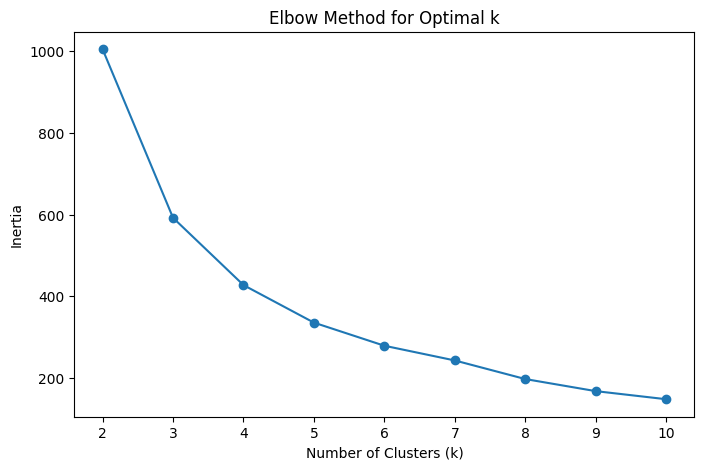

In [8]:
# Cell 8: Elbow method
inertia = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

In [9]:
# Cell 9: Silhouette scores
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    print(f"k={k}, Silhouette Score={score:.4f}")

k=2, Silhouette Score=0.5068
k=3, Silhouette Score=0.5222
k=4, Silhouette Score=0.5329
k=5, Silhouette Score=0.4112
k=6, Silhouette Score=0.4492
k=7, Silhouette Score=0.4469
k=8, Silhouette Score=0.4443
k=9, Silhouette Score=0.4438
k=10, Silhouette Score=0.4556


In [10]:
# Cell 10: Final KMeans model
best_k = 3  # change this after reviewing the results

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

numeric_df["cluster"] = clusters
numeric_df.head()

,customer_id,age,salary,purchased,cluster
0,1,35,500,0,2
1,2,25,300000,1,2
2,3,100,200000,0,2
3,15566689,35,57000,0,0
4,15569641,58,95000,1,1


In [11]:
# Cell 11: Add cluster labels to original dataframe
df_clustered = df.loc[numeric_df.index].copy()
df_clustered["cluster"] = clusters

df_clustered.head()

,customer_id,gender,age,salary,purchased,cluster
0,1,Male,35,500,0,2
1,2,Female,25,300000,1,2
2,3,Female,100,200000,0,2
3,15566689,Female,35,57000,0,0
4,15569641,Female,58,95000,1,1


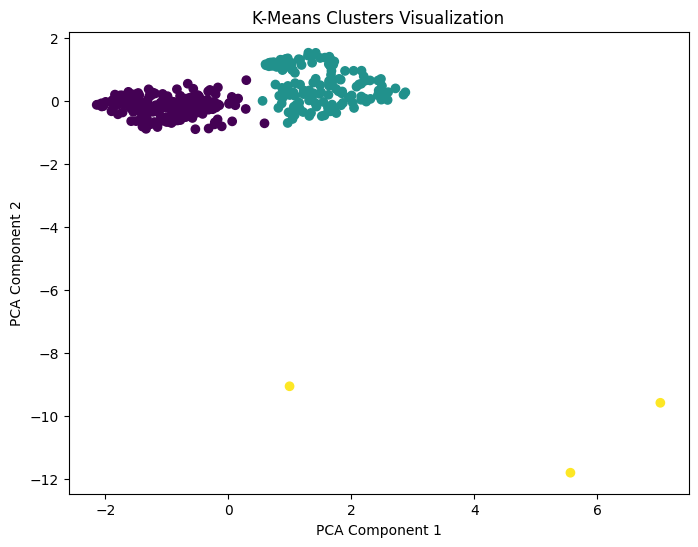

In [12]:
# Cell 12: PCA visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_data[:, 0], pca_data[:, 1], c=clusters)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clusters Visualization")
plt.show()

In [13]:
# Cell 13: Cluster summary
cluster_summary = df_clustered.groupby("cluster").mean(numeric_only=True)
cluster_summary

,customer_id,age,salary,purchased
cluster,,,,
0,1.569164e+07,32.482213,59636.363636,0.000000
1,1.569136e+07,46.557823,87136.054422,0.972789
2,2.000000e+00,53.333333,166833.333333,0.333333
